In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [2]:
experiment_dir = Path("/dcs/large/u1508153/misdro/kl_newsvendor_5d")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
for _, row in all_results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "kl_dro_bas":
        num_total_samples.append(row["num_likelihood_samples"])
all_results_df["num_total_samples"] = num_total_samples

In [3]:
# NOTE filter by DGP
results_df = all_results_df.loc[all_results_df["dgp"] == "multivariate_normal"]

# NOTE filter out when log_partition_constant G is less than epsilon
results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

results_df

mean_cost     var_cost  \
uuid                                 replication                            
054eb61c-e9b2-4d42-a932-638c13963ac3 0             91.088410  2699.580063   
                                     1            155.243745  8190.439671   
                                     2            106.484452  4633.879346   
                                     3            230.456077  9000.695639   
                                     4             95.340273  1296.674560   
...                                                      ...          ...   
f1ef55d8-cc35-43c5-ab78-034e0c143154 195          104.039041  2323.567535   
                                     196          177.898763  3673.092157   
                                     197          167.388866  2391.777138   
                                     198          173.457675  2621.542445   
                                     199          154.619782  3091.818269   

                                                                                           solution  \
uuid                                 replication                                                      
054eb61c-e9b2-4d42-a932-638c13963ac3 0            [10.914225955288524, 21.524084659466368, 34.44...   
                                     1            [11.572520388599, 17.65936580511073, 24.350915...   
                                     2            [11.852526924283396, 21.814547508419185, 31.65...   
                                     3            [10.140900541582589, 15.49786425188653, 21.143...   
                                     4            [10.667041041613647, 23.908137867425676, 35.72...   
...                                                                                             ...   
f1ef55d8-cc35-43c5-ab78-034e0c143154 195          [11.559317657704923, 22.541596503166648, 36.03...   
                                     196          [9.477864310512517, 26.830877094600673, 42.889...   
                                     197          [12.885494167511895, 26.56248463631784, 44.994...   
                                     198          [11.201751184380665, 28.789127058420945, 42.02...   
                                     199          [10.775436169269028, 27.958389408385997, 42.27...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
054eb61c-e9b2-4d42-a932-638c13963ac3 0            0.081331         0.000228   
                                     1            0.002790         0.000353   
                                     2            0.003898         0.000450   
                                     3            0.002455         0.000295   
                                     4            0.002963         0.000335   
...                                                    ...              ...   
f1ef55d8-cc35-43c5-ab78-034e0c143154 195          0.001747         0.009203   
                                     196          0.001381         0.009199   
                                     197          0.001393         0.009203   
                                     198          0.001383         0.009174   
                                     199          0.001388         0.009182   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
054eb61c-e9b2-4d42-a932-638c13963ac3 0                  0.000188    0.200581   
                                     1                  0.000308    0.045365   
                                     2                  0.000419    0.043426   
                                     3                  0.000272    0.043148   
                                     4                  0.000266    0.052081   
...                                                          ...         ...   
f1ef55d8-cc35-43c5-ab78-034e0c143154 195 

In [4]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior", "num_posterior_samples", "num_likelihood_samples"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    # "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                                                                            mean   
algorithm  dgp                 epsilon inference posterior              num_posterior_samples num_likelihood_samples               
kl_bdro    multivariate_normal 0.001   bayes     normal_inverse_wishart 5                     5                       144.346061   
                                                                        10                    10                      124.357373   
                                                                        30                    30                      110.220292   
                                                                        50                    50                      109.649783   
                               0.002   bayes     normal_inverse_wishart 5                     5                       144.522475   
...                                                                                                                          ...   
kl_dro_bas multivariate_normal 2.500   bayes     normal_inverse_wishart 1                     2500                    156.171840   
                               3.000   bayes     normal_inverse_wishart 1                     25                      141.405410   
                                                                                              100                     135.274080   
                                                                                              900                     156.145050   
                                                                                              2500                    166.430326   

                                                                                                                                   \
                                                                                                                              var   
algorithm  dgp                 epsilon inference posterior              num_posterior_samples num_likelihood_samples                
kl_bdro    multivariate_normal 0.001   bayes     normal_inverse_wishart 5                     5                       3535.530416   
                                                                        10                    10                       969.899071   
                                                                        30                    30                       204.834780   
                                                                        50                    50                       202.457011   
                               0.002   bayes     normal_inverse_wishart 5                     5                       3554.695108   
...                                                                                                                           ...   
kl_dro_bas multivariate_normal 2.500   bayes     normal_inverse_wishart 1                     2500                     799.695792   
                               3.000   bayes     normal_inverse_wishart 1                     25                      2968.356572   
                                                                                              100                     1532.096427   
                                                                                              900                     1104.691168   
                                                                                              2500                    1087.079867   

                                                                                                                         var_cost  \
                                                                                                                             mean   
algorithm  dgp                 epsilon inference posterior              num_posterior_samples num_likelihood_samples                
kl_bdro 

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


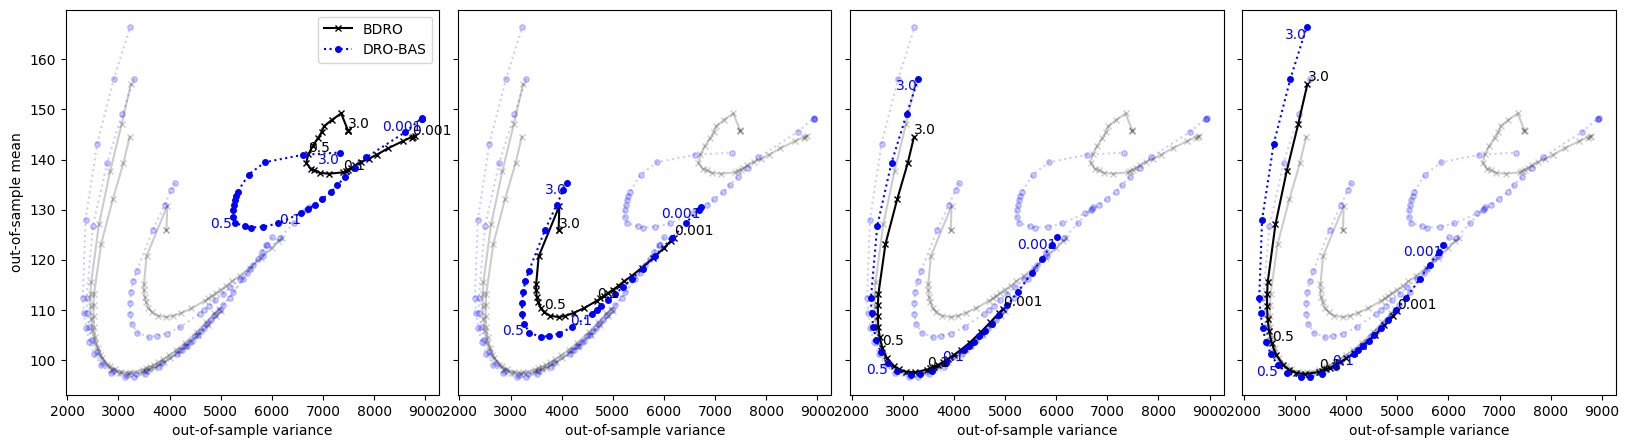

In [5]:
from mis_dro.plot import mean_variance_plot, algorithm_style, AlgorithmColor

from enum import StrEnum

def mean_variance_plot(
    axis,
    df: pd.DataFrame,
    is_labelled: bool = True,
    **kwargs,
) -> None:
    posterior_var = df["var_cost"]["mean"] + df["mean_cost"]["var"]

    # plot mean-variance trade-off
    epsilon_list = list(df.index.get_level_values("epsilon"))
    axis.plot(posterior_var, df["mean_cost"]["mean"], **kwargs, markersize=4)
    # axis.scatter(posterior_var, df["mean_cost"]["mean"], s=100*np.sqrt(np.array(epsilon_list)), **kwargs)
    if is_labelled:
        
        for i, epsilon in enumerate(epsilon_list):
            # if i % 4 == 0:

            if i == 0 or i == len(epsilon_list) - 1 or epsilon in (0.1, 0.5):
                # if line is blue then put text on bottom left
                if kwargs["color"] == AlgorithmColor.kl_dro_bas:
                    ha = "right"
                    va = "top"
                    # offset = -1 if i==0 or i == len(epsilon_list) else -5
                    offset = -1

                # else if line is black then put text on top right
                elif kwargs["color"] == AlgorithmColor.kl_bdro:
                    ha = "left"
                    va = "bottom"
                    # offset = 1 if i==0 or i == len(epsilon_list) else 5
                    offset = 1

                axis.text(
                    posterior_var[:, :, epsilon, :].iloc[0] + offset,
                    df["mean_cost"]["mean"][:, :, epsilon, :].iloc[0],
                    epsilon,
                    ha=ha,
                    va=va,
                    color=kwargs["color"],
                )

class NiceNameDGP(StrEnum):
    normal = "Normal DGP"
    truncated_normal = "Truncated Normal DGP"

# NOTE if you want to visual only one DGP, then uncomment the below lines
# only_dgp = "normal"
# agg_df = agg_df.loc[:, only_dgp, :, :]

compare_col="algorithm"
gb_col="dgp"
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

TOTAL_SAMPLES = [25, 100, 900, 2500]
nrows = len(agg_df.index.get_level_values("dgp").unique())
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[(
        (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
        | (likelihood_sr == total_samples) & (posterior_sr == 1)
    )]
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    gb = df.groupby(gb_col)

    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
        else:
            alpha = 0.2
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                    group_df.index.get_level_values("inference"),
                    group_df.index.get_level_values("posterior"),
                )
            )
            if k == 0:
                axes[k].set_ylabel("out-of-sample mean")
                axes[k].legend()
            axes[k].set_xlabel("out-of-sample variance")

            # axes[i, k].set_title(f"{NiceNameDGP[group].value} with {n_total_samples_sqrt**2} samples")
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp, inference, posterior in index_set:
                style = algorithm_style(algorithm)
                line_label = ""
                if k == 0 and j == k:
                    line_label = style.pop("label")
                else:
                    style.pop("label")
                mean_variance_plot(axes[k], group_df.loc[algorithm, dgp, :np.inf, inference, posterior], **style, alpha=alpha, is_labelled=is_labelled, label=line_label)

fig.show()

## Solve time

In [47]:
results_df["is_warm_start"] = results_df.index.get_level_values("replication") == 0

# solve_time_df = results_df.groupby(["algorithm", "dgp", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="dgp").unstack(level="algorithm")
solve_time_df = results_df.groupby(["algorithm", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="algorithm").swaplevel(1,2, axis="columns")

solve_time_df


solve_time                                
algorithm                          kl_bdro kl_dro_bas   kl_bdro kl_dro_bas
                                      mean       mean       std        std
num_total_samples is_warm_start                                           
25                False           0.021581   0.021601  0.003978   0.005241
                  True            0.090382   0.039646  0.032785   0.031937
100               False           0.069394   0.123321  0.009965   0.046306
                  True            0.250966   0.101109  0.021789   0.010008
900               False           0.748535   1.492742  0.082733   0.299122
                  True           30.494229   1.325020  0.131563   0.115197
2500              False           3.142916   7.818389  0.124957   0.396536
                  True            3.177352   7.710465  0.094772   0.272650

In [7]:
print(solve_time_df.to_latex())

\begin{tabular}{llrrrr}
\toprule
 &  & \multicolumn{4}{r}{solve_time} \\
 & algorithm & kl_bdro & kl_dro_bas & kl_bdro & kl_dro_bas \\
 &  & mean & mean & std & std \\
num_total_samples & is_warm_start &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{25} & False & 0.021581 & 0.021601 & 0.003978 & 0.005241 \\
 & True & 0.090382 & 0.039646 & 0.032785 & 0.031937 \\
\cline{1-6}
\multirow[t]{2}{*}{100} & False & 0.069394 & 0.123321 & 0.009965 & 0.046306 \\
 & True & 0.250966 & 0.101109 & 0.021789 & 0.010008 \\
\cline{1-6}
\multirow[t]{2}{*}{900} & False & 0.748535 & 1.492742 & 0.082733 & 0.299122 \\
 & True & 30.494229 & 1.325020 & 0.131563 & 0.115197 \\
\cline{1-6}
\multirow[t]{2}{*}{2500} & False & 3.142916 & 7.818389 & 0.124957 & 0.396536 \\
 & True & 3.177352 & 7.710465 & 0.094772 & 0.272650 \\
\cline{1-6}
\bottomrule
\end{tabular}



# Constant $G(\tau_n)$ and expected KL

In [8]:

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_log_partition_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_log_partition_constant("normal_gamma", theta_posterior)

dgp = "multivariate_normal"
posterior = "normal_inverse_wishart"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_log_partition_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

ValueError: Dimension mismatch: array 'cov' is of shape (1, 1), but 'mean' is a vector of length 5.

In [ ]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.08892539135699731, 0.0022999465683889984)

In [ ]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.7442957726813, 0.0)

# Mean squared error between our solution and the solution under the DGP


In [ ]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 809.5869569415518, 16.31412063772674)

In [41]:
def multivariate_digamma(a: float, p: int) -> float:
    """The multivariate digamma function of dimension p

    Notes:
        [1] https://search.r-project.org/CRAN/refmans/CholWishart/html/mvdigamma.html
        [2] https://en.wikipedia.org/wiki/Multivariate_gamma_function#Derivatives
    """
    return np.sum([sp.special.digamma(a + (1.0-i)/2.0) for i in range(p)])

def get_normal_inverse_wishart_G_constant(dim: int, kappa_post: float) -> float:
    """Returns the constant G(tau, nu) for the normal-inverse-Wishart"""
    term1 = -0.5 * dim * np.log(2)
    print(term1)
    term2 = - 0.5 * multivariate_digamma(0.5 * (kappa_post - dim - 2), dim)
    print(term2)
    term3 = dim / (2 * kappa_post)
    print(term3)
    term4 = dim * 0.5 * np.log(kappa_post - dim - 2)
    print(term4)
    # term5 = 0.5 * np.log(dim)
    # print(term5)
    return term1 + term2 + term3 + term4

In [48]:
dim = 5
_, kappa_prior, _, _ = default_prior_params("normal_inverse_wishart", dim=dim)
kappa_post = kappa_prior +  20
kappa_prior, kappa_post

(13.0, 33.0)

In [49]:
get_normal_inverse_wishart_G_constant(dim, kappa_post)

-1.7328679513998633
-6.208643562685282
0.07575757575757576
8.145241345053705


0.2794874067261359

3.6796019841580883